# Dataset Preprocessing

## Mount Google Drive & Set Paths

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define base directory where the files are stored
base_path = "/content/drive/MyDrive/QML/"

# Define paths for Healthy and MCI folders
healthy_path = os.path.join(base_path, "Healthy")
mci_path = os.path.join(base_path, "MCI")

In [ ]:
print(healthy_path)
print(mci_path)

/content/drive/MyDrive/QML/Healthy
/content/drive/MyDrive/QML/MCI


## Load and Label Files Based on Parent Folder

In [ ]:
def load_csv_files_by_modality(folder_path, data_type, label):
    """
    Loads all CSV files of a specific type (EEG, HRV, Pose) from a folder.
    Assigns the corresponding label (Healthy/MCI) based on the folder structure.
    """
    files = glob.glob(os.path.join(folder_path, f"*{data_type}*.csv"))  # Match only relevant files
    data_list = []

    for file in files:
        df = pd.read_csv(file)
        df["Label"] = label  # Assign label based on parent folder
        df["Filename"] = os.path.basename(file)
        data_list.append(df)

    return data_list

# Load EEG, HRV, and Pose datasets separately
eeg_healthy = load_csv_files_by_modality(healthy_path, "eeg", "Healthy")
eeg_mci = load_csv_files_by_modality(mci_path, "eeg", "MCI")
hrv_healthy = load_csv_files_by_modality(healthy_path, "hrv", "Healthy")
hrv_mci = load_csv_files_by_modality(mci_path, "hrv", "MCI")
pose_healthy = load_csv_files_by_modality(healthy_path, "walking_pose", "Healthy")  # Adjust based on naming
pose_mci = load_csv_files_by_modality(mci_path, "walking_pose", "MCI")

# Merge Healthy & MCI datasets
eeg_data_list = eeg_healthy + eeg_mci
hrv_data_list = hrv_healthy + hrv_mci
pose_data_list = pose_healthy + pose_mci

print(f"✅ Loaded {len(eeg_data_list)} EEG files, {len(hrv_data_list)} HRV files, {len(pose_data_list)} Pose files.")

✅ Loaded 121 EEG files, 120 HRV files, 120 Pose files.


## Synchronization & Normalization

In [ ]:
def normalize_features(df, feature_cols):
    """Applies Min-Max normalization to selected columns."""
    scaler = MinMaxScaler()
    df[feature_cols] = scaler.fit_transform(df[feature_cols])
    return df

def synchronize_data(eeg_df, hrv_df, pose_df):
    """
    Aligns timestamps across EEG, HRV, and Pose data using interpolation.
    Preserves class labels.
    """
    min_time = max(eeg_df["Timestamp"].min(), hrv_df["Timestamp"].min(), pose_df["Timestamp"].min())
    max_time = min(eeg_df["Timestamp"].max(), hrv_df["Timestamp"].max(), pose_df["Timestamp"].max())

    common_timestamps = np.linspace(min_time, max_time, num=len(eeg_df))

    hrv_interp = np.interp(common_timestamps, hrv_df["Timestamp"], hrv_df["HRV"])
    pose_interp = {col: np.interp(common_timestamps, pose_df["Timestamp"], pose_df[col])
                   for col in pose_df.columns if col not in ["Timestamp", "Label", "Filename"]}

    # Replace timestamps and retain labels
    eeg_df["Timestamp"] = common_timestamps
    hrv_aligned = pd.DataFrame({"Timestamp": common_timestamps, "HRV": hrv_interp,
                                "Label": hrv_df["Label"].iloc[0], "Filename": hrv_df["Filename"].iloc[0]})

    pose_aligned = pd.DataFrame({"Timestamp": common_timestamps})
    for col, interp_vals in pose_interp.items():
        pose_aligned[col] = interp_vals

    pose_aligned["Label"] = pose_df["Label"].iloc[0]
    pose_aligned["Filename"] = pose_df["Filename"].iloc[0]

    return eeg_df, hrv_aligned, pose_aligned

In [ ]:
# Process all datasets
processed_data = []
for eeg_df, hrv_df, pose_df in zip(eeg_data_list, hrv_data_list, pose_data_list):

    print(eeg_df)
    print(hrv_df)
    print(pose_df)
    eeg_df, hrv_df, pose_df = synchronize_data(eeg_df, hrv_df, pose_df)

    # Normalize features
    eeg_feature_cols = [col for col in eeg_df.columns if col not in ["Timestamp", "Label", "Filename"]]
    eeg_df = normalize_features(eeg_df, eeg_feature_cols)

    hrv_df = normalize_features(hrv_df, ["HRV"])

    pose_feature_cols = [col for col in pose_df.columns if col not in ["Timestamp", "Label", "Filename"]]
    pose_df = normalize_features(pose_df, pose_feature_cols)

    processed_data.append((eeg_df, hrv_df, pose_df))

Streaming output truncated to the last 5000 lines.
8996    0.281969    -0.281969 -8.672447e+00  8.672447e+00  27.602813   
8997    2.529154    -2.529154 -5.920233e+00  5.920233e+00  29.747470   
8998    4.705487    -4.705487 -3.002168e+00  3.002168e+00  31.058777   
8999    6.750000    -6.750000 -3.104458e-12  1.252146e-12  31.500000   

      Right Knee  Left Ankle  Right Ankle Label  \
0     -31.500000   25.455844   -25.455844   MCI   
1     -31.058777   29.344989   -29.344989   MCI   
2     -29.747470   32.412059   -32.412059   MCI   
3     -27.602813   34.571134   -34.571134   MCI   
4     -24.684887   35.761728   -35.761728   MCI   
...          ...         ...          ...   ...   
8995  -24.684887    4.135074    -4.135074   MCI   
8996  -27.602813   10.041749   -10.041749   MCI   
8997  -29.747470   15.667113   -15.667113   MCI   
8998  -31.058777   20.853576   -20.853576   MCI   
8999  -31.500000   25.455844   -25.455844   MCI   

                                               

## Save Preprocessed Data

In [ ]:
# Create output directory
output_path = "/content/drive/MyDrive/QML/Preprocessed/"
os.makedirs(output_path, exist_ok=True)

# Save preprocessed files
for idx, (eeg_df, hrv_df, pose_df) in enumerate(processed_data):
    eeg_df.to_csv(f"{output_path}/eeg_preprocessed_{idx}.csv", index=False)
    hrv_df.to_csv(f"{output_path}/hrv_preprocessed_{idx}.csv", index=False)
    pose_df.to_csv(f"{output_path}/pose_preprocessed_{idx}.csv", index=False)

print("✅ Preprocessing complete! Files saved in:", output_path)


✅ Preprocessing complete! Files saved in: /content/drive/MyDrive/QML/Preprocessed/


# Feature Extraction


## EEG Feature Extraction

### Setup and Load EEG

In [ ]:
!pip install mne

In [ ]:
!pip install PyWavelets

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import mne
import pywt
from scipy.signal import welch
from scipy.stats import skew, kurtosis
from google.colab import drive

In [ ]:
# Set EEG preprocessed data path
eeg_path = "/content/drive/MyDrive/QML/Preprocessed"
output_path = "/content/drive/MyDrive/QML/Features/"
os.makedirs(output_path, exist_ok=True)

# Load EEG files
eeg_files = glob.glob(os.path.join(eeg_path, "eeg_preprocessed_*.csv"))
print(f"✅ Found {len(eeg_files)} EEG files.")

✅ Found 120 EEG files.


### Define Feature Extraction Functions

In [ ]:
def sliding_window(data, window_size, step_size):
    """
    Splits data into overlapping windows.
    """
    for start in range(0, len(data) - window_size + 1, step_size):
        yield start, data[start:start + window_size]

In [ ]:
def compute_psd(eeg_data, fs=256):
    """Computes Power Spectral Density (PSD) for each EEG channel."""
    psd_features = {}
    freqs, psd = welch(eeg_data, fs=fs, nperseg=fs*2)  # Welch method
    bands = {"Delta": (0.5, 4), "Theta": (4, 8), "Alpha": (8, 13),
             "Beta": (13, 30), "Gamma": (30, 50)}

    for band, (low, high) in bands.items():
        band_power = np.sum(psd[(freqs >= low) & (freqs <= high)])
        psd_features[f"PSD_{band}"] = band_power
    return psd_features

def compute_entropy(eeg_signal):
    """Computes Shannon and Sample Entropy."""
    shannon_entropy = -np.sum(eeg_signal * np.log2(eeg_signal + 1e-10))
    sample_entropy = np.std(eeg_signal) * np.log2(np.var(eeg_signal + 1e-10))
    return {"Shannon_Entropy": shannon_entropy, "Sample_Entropy": sample_entropy}

def compute_wavelet_features(eeg_signal):
    """Extracts Wavelet Transform features from EEG signals."""
    coeffs = pywt.wavedec(np.array(eeg_signal, copy=True), 'db4', level=4)
    wavelet_features = {f"Wavelet_C{i}": np.mean(np.abs(coeff)) for i, coeff in enumerate(coeffs)}
    return wavelet_features

def compute_statistical_features(eeg_signal):
    """Extracts statistical features (Mean, Std, Skewness, Kurtosis)."""
    return {
        "Mean": np.mean(eeg_signal),
        "Std": np.std(eeg_signal),
        "Skewness": skew(eeg_signal),
        "Kurtosis": kurtosis(eeg_signal)
    }

### Process EEG Data & Extract Features

In [ ]:
def extract_windowed_eeg_features(eeg_signal, patient_id, label, fs=256, window_size=256, step_size=128):
    """
    Extracts features per window for an EEG signal.
    """
    features = []
    for start, window in sliding_window(eeg_signal, window_size, step_size):
        psd_feats = compute_psd(window, fs)
        entropy_feats = compute_entropy(window)
        wavelet_feats = compute_wavelet_features(window)
        stat_feats = compute_statistical_features(window)

        row = {
            "Patient_ID": patient_id,
            "Modality": "EEG",
            "Window_Start": start,
            "Window_End": start + window_size,
            "Label": label
        }
        row.update(psd_feats)
        row.update(entropy_feats)
        row.update(wavelet_feats)
        row.update(stat_feats)
        features.append(row)
    return pd.DataFrame(features)


## HRV Feature Extraction

### Setup and Load HRV Data

In [ ]:
!pip install pyhrv

In [ ]:
!pip install peakutils

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import pyhrv
from scipy.stats import skew, kurtosis

In [ ]:
# Set HRV preprocessed data path
hrv_path = "/content/drive/MyDrive/QML/Preprocessed/"
output_path = "/content/drive/MyDrive/QML/Features/"
os.makedirs(output_path, exist_ok=True)

# Load HRV files
hrv_files = glob.glob(os.path.join(hrv_path, "hrv_preprocessed_*.csv"))
print(f"✅ Found {len(hrv_files)} HRV files.")

✅ Found 120 HRV files.


### Define HRV Feature Extraction Functions

In [ ]:
def compute_time_domain_features(rr_intervals):
    """Extracts time-domain HRV features."""
    rr_intervals = np.array(rr_intervals)
    diff_rr = np.diff(rr_intervals)

    return {
        "Mean_RR": np.mean(rr_intervals),
        "SDNN": np.std(rr_intervals),
        "RMSSD": np.sqrt(np.mean(diff_rr**2)),
        "pNN50": np.sum(diff_rr > 50) / len(diff_rr) * 100
    }

from scipy.signal import welch
from scipy.integrate import trapezoid

def compute_frequency_domain_features(rr_intervals, fs=4.0):
    """Computes frequency-domain HRV features using Welch PSD instead of pyHRV."""
    if len(rr_intervals) < 10:
        print("⚠️ Not enough RR intervals for frequency analysis.")
        return {"LF": np.nan, "HF": np.nan, "LF_HF_Ratio": np.nan}

    try:
        # Estimate power spectral density using Welch's method
        freqs, psd = welch(rr_intervals, fs=fs, nperseg=len(rr_intervals)//2)

        # Define LF (0.04-0.15 Hz) and HF (0.15-0.40 Hz) bands
        lf_band = (0.04, 0.15)
        hf_band = (0.15, 0.40)

        # Compute power within frequency bands
        lf_power = trapezoid(psd[(freqs >= lf_band[0]) & (freqs <= lf_band[1])],
                     freqs[(freqs >= lf_band[0]) & (freqs <= lf_band[1])])

        hf_power = trapezoid(psd[(freqs >= hf_band[0]) & (freqs <= hf_band[1])],
                            freqs[(freqs >= hf_band[0]) & (freqs <= hf_band[1])])

        # Compute LF/HF Ratio (avoid division by zero)
        lf_hf_ratio = lf_power / (hf_power + 1e-10)

        return {"LF": lf_power, "HF": hf_power, "LF_HF_Ratio": lf_hf_ratio}

    except Exception as e:
        print(f"⚠️ Error in LF/HF computation: {e}")
        return {"LF": np.nan, "HF": np.nan, "LF_HF_Ratio": np.nan}

import nolds

def compute_nonlinear_features(rr_intervals):
    """Computes nonlinear HRV features (Sample Entropy, DFA) using alternative methods."""
    try:
        sample_entropy = -np.sum(rr_intervals * np.log2(rr_intervals + 1e-10))
        dfa_value = nolds.dfa(rr_intervals)  # Alternative DFA computation
        return {"Sample_Entropy": sample_entropy, "DFA": dfa_value}
    except Exception as e:
        print(f"⚠️ Error in DFA computation: {e}")
        return {"Sample_Entropy": np.nan, "DFA": np.nan}

### Process HRV Data & Extract Features

In [ ]:
def extract_windowed_hrv_features(rr_intervals, patient_id, label, window_size=250, step_size=125):
    """
    Extracts HRV features per window.
    """
    features = []
    for start, window in sliding_window(rr_intervals, window_size, step_size):
        time_feats = compute_time_domain_features(window)
        freq_feats = compute_frequency_domain_features(window)
        nonlinear_feats = compute_nonlinear_features(window)

        row = {
            "Patient_ID": patient_id,
            "Modality": "HRV",
            "Window_Start": start,
            "Window_End": start + window_size,
            "Label": label
        }
        row.update(time_feats)
        row.update(freq_feats)
        row.update(nonlinear_feats)
        features.append(row)
    return pd.DataFrame(features)

## Pose Feature Extration

### Setup and Load Pose Data

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
from google.colab import drive

In [ ]:
# Set Pose preprocessed data path
pose_path = "/content/drive/MyDrive/QML/Preprocessed/"
output_path = "/content/drive/MyDrive/QML/Features/"
os.makedirs(output_path, exist_ok=True)

# Load Pose files
pose_files = glob.glob(os.path.join(pose_path, "pose_preprocessed_*.csv"))
print(f"✅ Found {len(pose_files)} Pose files.")

✅ Found 120 Pose files.


### Define Feature Extraction Functions

In [ ]:
def compute_joint_variability(df, joints):
    """Computes mean and standard deviation for selected joints, removing ROM since data is normalized."""
    features = {}
    for joint in joints:
        if joint in df.columns:
            features[f"{joint}_Mean"] = np.mean(df[joint])
            features[f"{joint}_Std"] = np.std(df[joint])
    return features

def compute_velocity_acceleration(df, joints):
    """Computes velocity, acceleration, and jerk for selected joints."""
    features = {}
    dt = 1 / 30  # Assuming 30 FPS (adjust if different)

    for joint in joints:
        if joint in df.columns:
            velocity = np.gradient(df[joint], dt)
            acceleration = np.gradient(velocity, dt)
            jerk = np.gradient(acceleration, dt)

            features[f"{joint}_Velocity_Mean"] = np.mean(velocity)
            features[f"{joint}_Acceleration_Mean"] = np.mean(acceleration)
            features[f"{joint}_Jerk_Mean"] = np.mean(jerk)
    return features

import pandas as pd
import numpy as np

from scipy.signal import find_peaks

def compute_spatiotemporal_gait_metrics(preprocessed_file, base_folder):
    """Extracts step length, stride length, and cadence using RAW pose data mapped via Label & Filename columns."""
    try:
        # Load preprocessed pose file
        df_preprocessed = pd.read_csv(preprocessed_file)

        # Retrieve original raw filename and label (Healthy/MCI)
        if "Filename" not in df_preprocessed.columns or "Label" not in df_preprocessed.columns:
            print(f"⚠️ Missing 'Filename' or 'Label' column in {preprocessed_file}. Cannot map to raw file.")
            return {"Step_Length_Mean": np.nan, "Stride_Length_Mean": np.nan, "Cadence": np.nan}

        original_filename = df_preprocessed["Filename"].iloc[0]
        label = df_preprocessed["Label"].iloc[0]

        # Construct raw file path dynamically
        raw_file_path = f"{base_folder}/{label}/{original_filename}"
        df_raw = pd.read_csv(raw_file_path)

        # Ensure timestamps are in seconds (convert if in ms)
        timestamps = df_raw["Timestamp"].values
        if timestamps[-1] > 1_000_000:  # If values are in milliseconds
            timestamps = timestamps / 1_000.0

        # Check duration
        duration = timestamps[-1] - timestamps[0]
        print(f"🔍 Duration: {duration} seconds")

        # Extract Left and Right Ankle data
        if "Left Ankle" not in df_raw.columns or "Right Ankle" not in df_raw.columns:
            print(f"⚠️ Left Ankle or Right Ankle column missing in {original_filename}.")
            return {"Step_Length_Mean": np.nan, "Stride_Length_Mean": np.nan, "Cadence": np.nan}

        left_foot = df_raw["Left Ankle"].values
        right_foot = df_raw["Right Ankle"].values

        # 🏃 **Fix Step Length Calculation**
        step_length = np.abs(np.diff(left_foot) - np.diff(right_foot))  # Take absolute diff
        stride_length = np.abs(np.diff(left_foot[::2]))  # Every second step

        # ⏳ **Fix Cadence Calculation using Peak Detection**
        peak_indices, _ = find_peaks(-left_foot, distance=20)  # Detect heel strikes
        num_steps = len(peak_indices)

        print(f"🔢 Number of Steps Counted: {num_steps}")

        # Final cadence calculation
        if duration > 0:
            cadence = (num_steps / duration) * 60  # Convert to steps per minute
        else:
            cadence = np.nan

        return {
            "Step_Length_Mean": np.mean(step_length),
            "Stride_Length_Mean": np.mean(stride_length),
            "Cadence": cadence
        }

    except Exception as e:
        print(f"⚠️ Error in gait metric computation for {preprocessed_file}: {e}")
        return {"Step_Length_Mean": np.nan, "Stride_Length_Mean": np.nan, "Cadence": np.nan}


### Process Pose Data & Extract Features

In [ ]:
def extract_windowed_pose_features(pose_df, joints, patient_id, label, window_size=30, step_size=15):
    """
    Extracts pose features per window from a pose DataFrame.
    """
    features = []
    for start in range(0, len(pose_df) - window_size + 1, step_size):
        window = pose_df.iloc[start:start + window_size]

        joint_feats = compute_joint_variability(window, joints)
        motion_feats = compute_velocity_acceleration(window, joints)

        row = {
            "Patient_ID": patient_id,
            "Modality": "Pose",
            "Window_Start": start,
            "Window_End": start + window_size,
            "Label": label
        }
        row.update(joint_feats)
        row.update(motion_feats)
        features.append(row)
    return pd.DataFrame(features)

## Merge EEG, HRV, and Pose Features

In [ ]:
# Define your folder paths
healthy_path = "/content/drive/MyDrive/QML/Healthy"
mci_path = "/content/drive/MyDrive/QML/MCI"

# Load EEG, HRV, and Pose files
eeg_healthy = load_csv_files_by_modality(healthy_path, "eeg", "Healthy")
eeg_mci = load_csv_files_by_modality(mci_path, "eeg", "MCI")

hrv_healthy = load_csv_files_by_modality(healthy_path, "hrv", "Healthy")
hrv_mci = load_csv_files_by_modality(mci_path, "hrv", "MCI")

pose_healthy = load_csv_files_by_modality(healthy_path, "walking_pose", "Healthy")
pose_mci = load_csv_files_by_modality(mci_path, "walking_pose", "MCI")

# Combine them into master lists
eeg_data_list = eeg_healthy + eeg_mci
hrv_data_list = hrv_healthy + hrv_mci
pose_data_list = pose_healthy + pose_mci

In [ ]:
from joblib import Parallel, delayed
from tqdm import tqdm

num_patients = min(len(eeg_data_list), len(hrv_data_list), len(pose_data_list))
num_workers = 4  # Adjust based on available CPU cores

def process_patient(i):
    eeg_df = eeg_data_list[i]
    hrv_df = hrv_data_list[i]
    pose_df = pose_data_list[i]

    # Interpolate HRV timestamps to 300s
    new_timestamps = np.arange(hrv_df["Timestamp"].min(), 300, step=1/250)  # 250Hz spacing
    hrv_df = hrv_df.set_index("Timestamp").reindex(new_timestamps, method="nearest").reset_index()
    hrv_df.rename(columns={"index": "Timestamp"}, inplace=True)

    patient_id = i + 1
    print(f"🔍 Processing Patient: {patient_id}")  # Debugging line

    eeg_features = extract_windowed_eeg_features(eeg_df.iloc[:, 0].values, patient_id, eeg_df["Label"].iloc[0])
    print(f"📊 EEG Features: {eeg_features.shape}")  # Debugging line

    hrv_features = extract_windowed_hrv_features(hrv_df.iloc[:, 0].values, patient_id, hrv_df["Label"].iloc[0])
    print(f"💓 HRV Features: {hrv_features.shape}")  # Debugging line

    pose_features = extract_windowed_pose_features(pose_df, [col for col in pose_df.columns if col not in ["Label", "Filename"]], patient_id, pose_df["Label"].iloc[0])
    print(f"🏃 Pose Features: {pose_features.shape}")  # Debugging line

    print("🔍 Unique Patient_IDs in EEG:", eeg_features["Patient_ID"].unique())
    print("💓 Unique Patient_IDs in HRV:", hrv_features["Patient_ID"].unique())
    print("🏃 Unique Patient_IDs in Pose:", pose_features["Patient_ID"].unique())

    print("🔍 EEG Start/End Sample:\n", eeg_features[["Window_Start", "Window_End"]].head())
    print("💓 HRV Start/End Sample:\n", hrv_features[["Window_Start", "Window_End"]].head())
    print("🏃 Pose Start/End Sample:\n", pose_features[["Window_Start", "Window_End"]].head())

    # Save each modality separately
    eeg_features.to_csv(f"/content/drive/MyDrive/QML/Features/eeg_features_{patient_id}.csv", index=False)
    hrv_features.to_csv(f"/content/drive/MyDrive/QML/Features/hrv_features_{patient_id}.csv", index=False)
    pose_features.to_csv(f"/content/drive/MyDrive/QML/Features/pose_features_{patient_id}.csv", index=False)

    print("✅ Saved EEG, HRV, and Pose separately. Long live modality queens!")

In [ ]:
process_patient(0)  # Try with the first patient manually

🔍 Processing Patient: 1
📊 EEG Features: (599, 21)
💓 HRV Features: (599, 14)
🏃 Pose Features: (599, 70)
🔍 Unique Patient_IDs in EEG: [1]
💓 Unique Patient_IDs in HRV: [1]
🏃 Unique Patient_IDs in Pose: [1]
🔍 EEG Start/End Sample:
    Window_Start  Window_End
0             0         256
1           128         384
2           256         512
3           384         640
4           512         768
💓 HRV Start/End Sample:
    Window_Start  Window_End
0             0         250
1           125         375
2           250         500
3           375         625
4           500         750
🏃 Pose Start/End Sample:
    Window_Start  Window_End
0             0          30
1            15          45
2            30          60
3            45          75
4            60          90
✅ Saved EEG, HRV, and Pose separately. Long live modality queens!


In [ ]:
# Parallel execution
results = Parallel(n_jobs=num_workers)(
    delayed(process_patient)(i) for i in tqdm(range(num_patients), desc="Processing patients in parallel")
)











Processing patients in parallel:   0%|          | 0/120 [00:00<?, ?it/s]









Processing patients in parallel:   3%|▎         | 4/120 [00:00<00:12,  8.98it/s]









Processing patients in parallel:   7%|▋         | 8/120 [01:54<31:17, 16.76s/it]









Processing patients in parallel:  10%|█         | 12/120 [03:40<38:12, 21.23s/it]









Processing patients in parallel:  13%|█▎        | 16/120 [05:29<40:54, 23.60s/it]









Processing patients in parallel:  17%|█▋        | 20/120 [07:20<41:50, 25.11s/it]









Processing patients in parallel:  20%|██        | 24/120 [09:07<41:09, 25.72s/it]









Processing patients in parallel:  23%|██▎       | 28/120 [10:58<40:22, 26.33s/it]









Processing patients in parallel:  27%|██▋       | 32/120 [12:46<38:59, 26.59s/it]









Processing patients in parallel:  30%|███       | 36/120 [14:37<37:43, 26.94s/it]









Processing patients in parallel:  33%|███▎      | 40/120 [16:26<35:59, 26.99s/it]











# Dataset Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

In [ ]:
# Load the merged dataset
file_path = "/content/drive/MyDrive/QML/Features/merged_windowed_features.csv"
df = pd.read_csv(file_path)

# Display basic info
print(f"✅ Dataset Loaded: {file_path}")
print(f"🔍 Shape: {df.shape}")
print(f"📝 Columns: {df.columns.tolist()}\n")

✅ Dataset Loaded: /content/drive/MyDrive/QML/Features/merged_windowed_features.csv
🔍 Shape: (0, 97)
📝 Columns: ['Patient_ID', 'Modality_EEG', 'Window_Start', 'Window_End', 'Label', 'PSD_Delta', 'PSD_Theta', 'PSD_Alpha', 'PSD_Beta', 'PSD_Gamma', 'Shannon_Entropy', 'Sample_Entropy_EEG', 'Wavelet_C0', 'Wavelet_C1', 'Wavelet_C2', 'Wavelet_C3', 'Wavelet_C4', 'Mean', 'Std', 'Skewness', 'Kurtosis', 'Modality_HRV', 'Mean_RR', 'SDNN', 'RMSSD', 'pNN50', 'LF', 'HF', 'LF_HF_Ratio', 'Sample_Entropy_HRV', 'DFA', 'Modality', 'Timestamp_Mean', 'Timestamp_Std', 'Left Shoulder_Mean', 'Left Shoulder_Std', 'Right Shoulder_Mean', 'Right Shoulder_Std', 'Left Elbow_Mean', 'Left Elbow_Std', 'Right Elbow_Mean', 'Right Elbow_Std', 'Left Wrist_Mean', 'Left Wrist_Std', 'Right Wrist_Mean', 'Right Wrist_Std', 'Left Hip_Mean', 'Left Hip_Std', 'Right Hip_Mean', 'Right Hip_Std', 'Left Knee_Mean', 'Left Knee_Std', 'Right Knee_Mean', 'Right Knee_Std', 'Left Ankle_Mean', 'Left Ankle_Std', 'Right Ankle_Mean', 'Right Ankle

In [ ]:
# 1️⃣ Check Class Distribution

# Drop non-numeric columns
df_numeric = df.select_dtypes(include=[np.number])

class_counts = df["Label"].value_counts()
print(f"🎯 Class Distribution:\n{class_counts}\n")

🎯 Class Distribution:
Series([], Name: count, dtype: int64)



<ipython-input-32-87e68fd3f7e1>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="Set2")


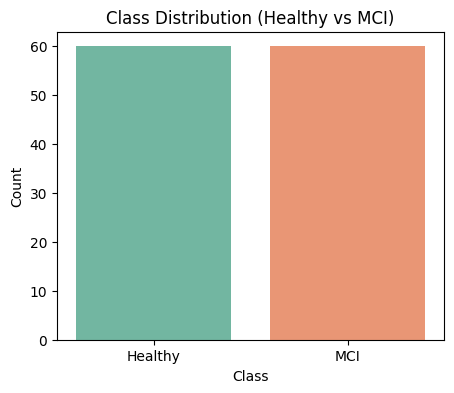

In [ ]:
# Plot class distribution
plt.figure(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="Set2")
plt.title("Class Distribution (Healthy vs MCI)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
# 2️⃣ Check Missing Values
missing_values = df.isnull().sum()
print(f"❌ Missing Values:\n{missing_values[missing_values > 0]}\n")

❌ Missing Values:
Series([], dtype: int64)



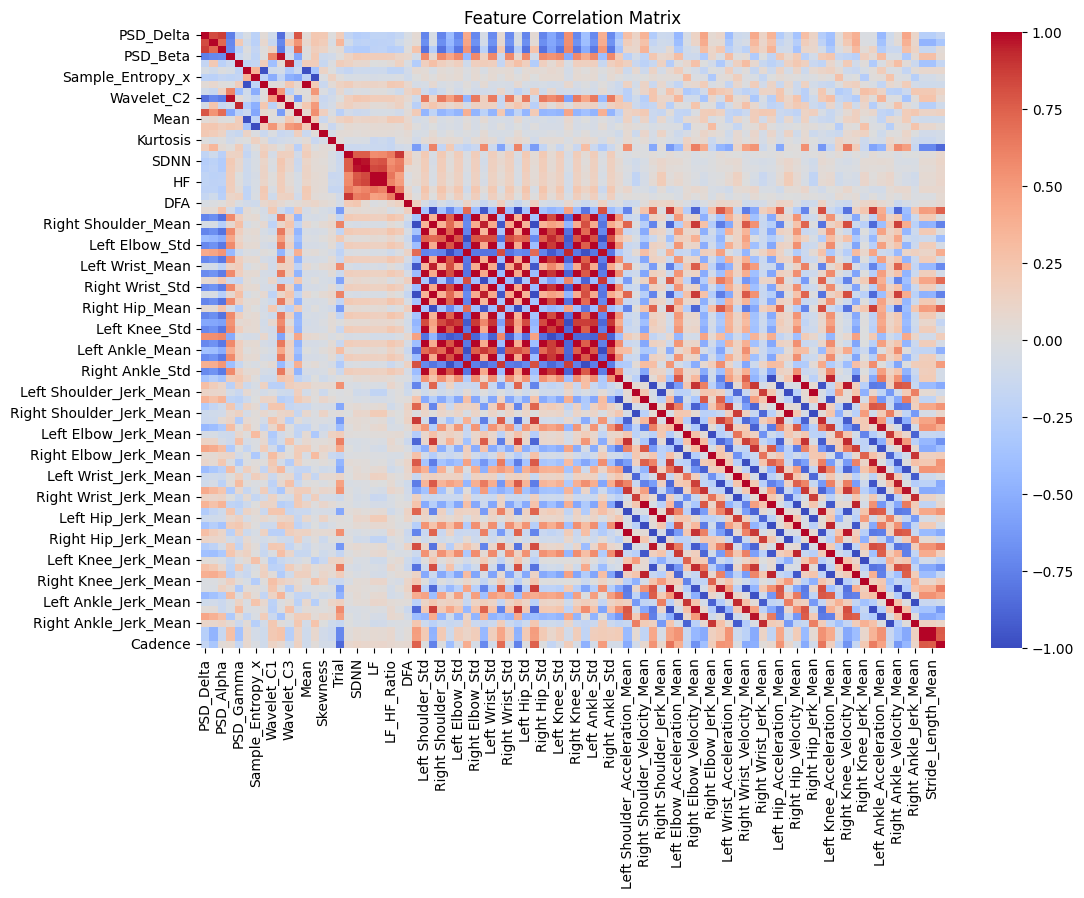

In [ ]:
# 3️⃣ Feature Correlations
plt.figure(figsize=(12, 8))
sns.heatmap(df_numeric.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
# 4️⃣ Detect Outliers using Z-score
z_scores = np.abs(zscore(df_numeric))
outliers = (z_scores > 3).sum()
print(f"⚠️ Outliers Detected in Features:\n{outliers[outliers > 0]}\n")

⚠️ Outliers Detected in Features:
PSD_Gamma                    1
Shannon_Entropy              1
Sample_Entropy_x             2
Wavelet_C3                   1
Std                          2
Kurtosis                     1
Mean_RR                      6
SDNN                         6
RMSSD                        6
LF_HF_Ratio                  4
Sample_Entropy_y             6
DFA                          1
Left Elbow_Mean              2
Right Elbow_Mean             2
Left Knee_Mean              10
Right Knee_Mean             10
Left Shoulder_Jerk_Mean      4
Right Shoulder_Jerk_Mean     4
Left Elbow_Jerk_Mean         5
Right Elbow_Jerk_Mean        5
Left Wrist_Jerk_Mean         5
Right Wrist_Jerk_Mean        5
Left Hip_Jerk_Mean           4
Right Hip_Jerk_Mean          4
Left Knee_Jerk_Mean          7
Right Knee_Jerk_Mean         7
Left Ankle_Jerk_Mean         6
Right Ankle_Jerk_Mean        6
dtype: int64



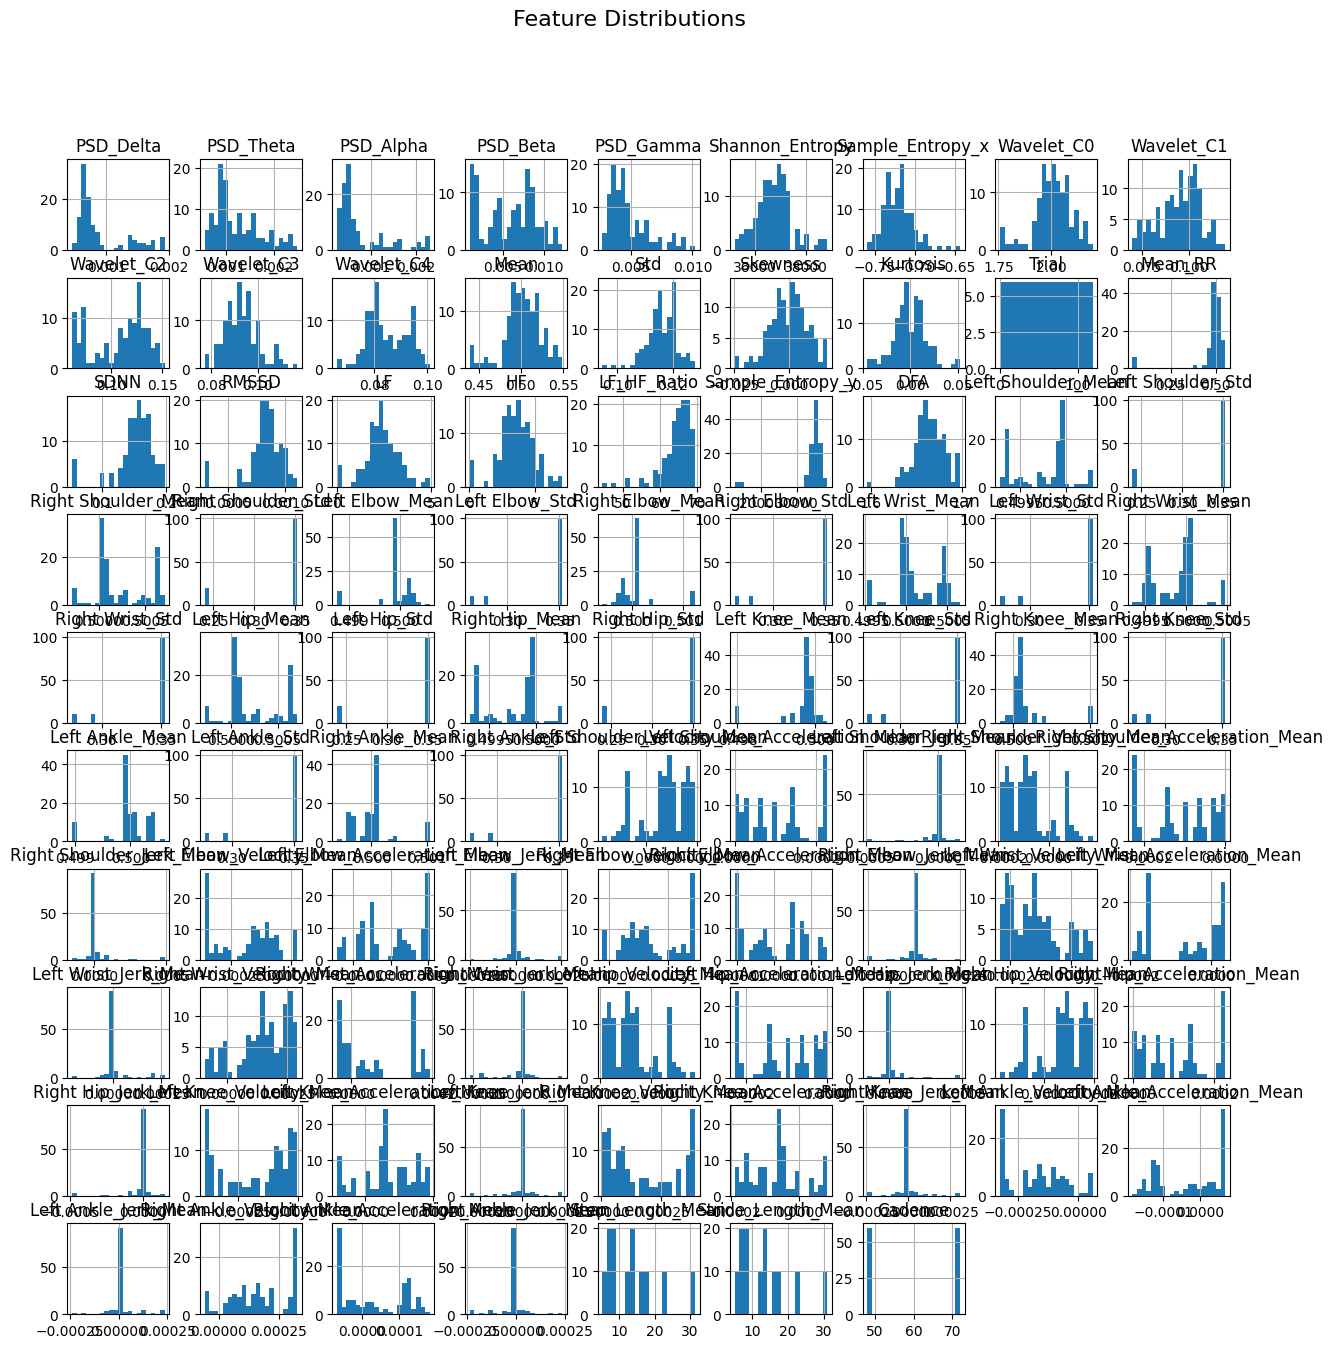

In [ ]:
# Plot feature distributions
df_numeric.hist(figsize=(15, 15), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()